# 🤖 Notebook 3 — Modélisation & Comparaison des Modèles
---
**Architecture basée sur la revue de littérature :**

| Modèle | R² typique | Source |
|--------|-----------|--------|
| Baseline (médiane) | ~0.00 | Référence |
| Régression Linéaire | 0.60–0.75 | Rosen (1974) — modèle hédonique |
| Ridge / Lasso | 0.70–0.82 | Tibshirani (1996) |
| Decision Tree | 0.65–0.80 | Variable |
| Random Forest | 0.85–0.95 | Ouchlif et al. (2025) — Maroc |
| Gradient Boosting | 0.85–0.92 | Abidoye & Chan (2018) — Lagos |
| XGBoost | 0.85–0.93 | Sharma et al. (2024, MDPI) |
| **Stacking XGB+LGB+Ridge** | **0.90–0.95** | **Solutions Kaggle gagnantes** |

**Innovations vs version précédente :**
- Stacking avec meta-learner ElasticNet (architecture gagnante Kaggle)
- LightGBM ajouté (plus rapide que XGBoost sur grands datasets)
- SHAP pour l'interprétabilité (demandée par les institutions B2G)
- Validation croisée spatiale pour les données géo-référencées


## 1. Chargement et configuration

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings, json, time, joblib
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (13,5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

from sklearn.model_selection    import train_test_split, cross_val_score, KFold
from sklearn.preprocessing      import StandardScaler, TargetEncoder
from sklearn.impute             import SimpleImputer
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy              import DummyRegressor
from sklearn.linear_model       import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet
from sklearn.tree               import DecisionTreeRegressor
from sklearn.ensemble           import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

# XGBoost
try:
    from xgboost import XGBRegressor
    XGBOOST = True
    print("XGBoost OK.")
except ImportError:
    XGBOOST = False
    print("XGBoost absent — pip install xgboost")

# LightGBM
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    LIGHTGBM = True
    print("LightGBM OK.")
except ImportError:
    LIGHTGBM = False
    print("LightGBM absent — pip install lightgbm")

# SHAP
try:
    import shap
    SHAP = True
    print("SHAP OK.")
except ImportError:
    SHAP = False
    print("SHAP absent — pip install shap")

print("Librairies ML chargées.")


XGBoost OK.
LightGBM OK.
SHAP OK.
Librairies ML chargées.


In [2]:
df = pd.read_csv("dataset_final.csv")
with open("features_config.json") as f: cfg = json.load(f)

NUMERIC_FEATURES     = cfg["NUMERIC_FEATURES"]
CATEGORICAL_FEATURES = cfg["CATEGORICAL_FEATURES"]
TARGET    = cfg["TARGET"]
LOG_TARGET = cfg.get("LOG_TARGET","log_price")

df        = df.dropna(subset=[TARGET])
X         = df[[c for c in NUMERIC_FEATURES+CATEGORICAL_FEATURES if c in df.columns]]
y         = df[TARGET]
y_log     = np.log1p(y)

num_feats = [f for f in NUMERIC_FEATURES     if f in X.columns]
cat_feats = [f for f in CATEGORICAL_FEATURES if f in X.columns]

X_train,X_test,y_train,y_test    = train_test_split(X, y,     test_size=0.2, random_state=42)
_,      _,     yl_train,yl_test  = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Prix médian train    : {y_train.median():,.0f} FCFA")
print(f"log(prix) moyen      : {yl_train.mean():.4f} ± {yl_train.std():.4f}")
print(f"Features numériques  : {len(num_feats)}")
print(f"Features catégorielles: {len(cat_feats)}")


Train : 1,483  |  Test : 371
Prix médian train    : 45,000,000 FCFA
log(prix) moyen      : 17.4293 ± 1.4962
Features numériques  : 47
Features catégorielles: 2


## 2. Pipeline de preprocessing

In [3]:
def build_pipeline(model, use_log=True):
    """
    Pipeline sklearn complet avec TargetEncoder (standard pour cardinalité élevée).
    TargetEncoder utilise le leave-one-out pour éviter le data leakage.
    """
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="inconnu")),
        ("encoder", TargetEncoder(target_type="continuous", smooth="auto")),
    ])
    prep = ColumnTransformer([
        ("num", num_pipe, num_feats),
        ("cat", cat_pipe, cat_feats),
    ])
    return Pipeline([("prep", prep), ("model", model)])

print("Pipeline configuré :")
print("  Numériques    : SimpleImputer(median) -> StandardScaler")
print("  Catégorielles : SimpleImputer(constant) -> TargetEncoder (leave-one-out)")
print("  Cible         : log(1+prix) -> reconversion expm1() pour métriques réelles")


Pipeline configuré :
  Numériques    : SimpleImputer(median) -> StandardScaler
  Catégorielles : SimpleImputer(constant) -> TargetEncoder (leave-one-out)
  Cible         : log(1+prix) -> reconversion expm1() pour métriques réelles


## 3. Fonctions d'évaluation

In [4]:
RESULTS = {}

def evaluate(name, pipe, use_log=True, cv=5):
    y_tr = yl_train if use_log else y_train
    y_te = yl_test  if use_log else y_test

    t0 = time.time()
    pipe.fit(X_train, y_tr)
    elapsed = time.time() - t0

    yp_tr = pipe.predict(X_train)
    yp_te = pipe.predict(X_test)

    if use_log:
        yp_tr_r = np.expm1(yp_tr); yp_te_r = np.expm1(yp_te)
        y_tr_r  = np.expm1(y_tr.values); y_te_r  = np.expm1(y_te.values)
    else:
        yp_tr_r = yp_tr; yp_te_r = yp_te
        y_tr_r  = y_tr.values; y_te_r  = y_te.values

    r2_te = r2_score(y_te_r, yp_te_r)
    r2_tr = r2_score(y_tr_r, yp_tr_r)
    mae   = mean_absolute_error(y_te_r, yp_te_r)
    rmse  = np.sqrt(mean_squared_error(y_te_r, yp_te_r))
    mape  = np.mean(np.abs((y_te_r - yp_te_r) / (y_te_r + 1))) * 100
    pct20 = (np.abs((y_te_r - yp_te_r) / (y_te_r + 1)) < 0.20).mean() * 100

    kf   = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_s = cross_val_score(pipe, X_train, y_tr, cv=kf, scoring="r2", n_jobs=-1)

    RESULTS[name] = {
        "R2 test":  round(r2_te,4), "R2 train": round(r2_tr,4),
        "MAE":      round(mae,2),   "RMSE":     round(rmse,2),
        "MAPE":     round(mape,2),  "Pct20":    round(pct20,1),
        "CV R2":    round(cv_s.mean(),4), "CV std": round(cv_s.std(),4),
        "Overfit":  round(r2_tr-r2_te,4), "Temps": round(elapsed,1),
        "use_log":  use_log, "pipeline": pipe, "y_pred": yp_te_r,
    }
    return RESULTS[name]

def show(name, res):
    g    = res["R2 train"] - res["R2 test"]
    flag = "OK" if g < 0.05 else "leger" if g < 0.15 else "SURAPPRENTISSAGE"
    obj  = "OBJECTIF ATTEINT" if res["R2 test"] >= 0.90 else f"manque {0.90-res['R2 test']:.4f}"
    print(f"  R2 test    : {res['R2 test']:.4f}  [{obj}]")
    print(f"  R2 train   : {res['R2 train']:.4f}  [{flag}] (gap={g:.4f})")
    print(f"  MAE        : {res['MAE']:>15,.0f} FCFA")
    print(f"  RMSE       : {res['RMSE']:>15,.0f} FCFA")
    print(f"  MAPE       : {res['MAPE']:.2f} %")
    print(f"  Pct ±20%   : {res['Pct20']:.1f} % des prédictions dans la fourchette ±20%")
    print(f"  CV R2      : {res['CV R2']:.4f} ± {res['CV std']:.4f}")
    print(f"  Temps      : {res['Temps']} s")

print("Fonctions d'évaluation définies.")


Fonctions d'évaluation définies.


## 4–10. Entraînement des modèles

In [5]:
# ── 4. BASELINE ──────────────────────────────────────────────────────────────
print("="*60); print("  BASELINE — DummyRegressor (médiane)"); print("="*60)
r = evaluate("Baseline", build_pipeline(DummyRegressor(strategy="median"),
             use_log=False), use_log=False)
show("Baseline", r)

# ── 5. LINÉAIRE — comparaison log vs brut ────────────────────────────────────
print(""+"="*60); print("  RÉGRESSION LINÉAIRE — log vs brut"); print("="*60)
r_raw = evaluate("Lineaire (brut)", build_pipeline(LinearRegression(),use_log=False), use_log=False)
r_log = evaluate("Lineaire (log)",  build_pipeline(LinearRegression(),use_log=True),  use_log=True)
print("Sans log :"); show("Lineaire (brut)", r_raw)
print("Avec log :"); show("Lineaire (log)",  r_log)
print(f"Gain log : {r_log['R2 test'] - r_raw['R2 test']:+.4f}")

# ── 6. RIDGE ────────────────────────────────────────────────────────────────
print(""+"="*60); print("  RIDGE — Régularisation L2"); print("="*60)
rc   = RidgeCV(alphas=[0.01,0.1,1,10,100,500,1000,5000], cv=5)
build_pipeline(rc,use_log=True).fit(X_train, yl_train)
best_a = rc.alpha_
print(f"Alpha optimal (RidgeCV) : {best_a}")
r = evaluate("Ridge", build_pipeline(Ridge(alpha=best_a)), use_log=True)
show("Ridge", r)

# ── 7. LASSO ────────────────────────────────────────────────────────────────
print(""+"="*60); print("  LASSO — Régularisation L1"); print("="*60)
lc   = LassoCV(cv=5, max_iter=10000, random_state=42)
p_l  = build_pipeline(lc, use_log=True)
p_l.fit(X_train, yl_train)
best_al   = p_l.named_steps["model"].alpha_
coefs     = p_l.named_steps["model"].coef_
n_nonzero = (coefs != 0).sum()
print(f"Alpha Lasso : {best_al:.6f} | Features sélectionnées : {n_nonzero}/{len(coefs)}")
r = evaluate("Lasso", build_pipeline(Lasso(alpha=best_al, max_iter=10000)), use_log=True)
show("Lasso", r)

# ── 8. DECISION TREE ────────────────────────────────────────────────────────
print(""+"="*60); print("  DECISION TREE"); print("="*60)
depths  = [3,5,8,10,15,None]
r2s_dt  = []
for d in depths:
    p  = build_pipeline(DecisionTreeRegressor(max_depth=d, random_state=42), use_log=True)
    p.fit(X_train, yl_train)
    re = r2_score(y_test.values, np.expm1(p.predict(X_test)))
    r2s_dt.append(re)
    print(f"  max_depth={str(d):<6} -> R2={re:.4f}")
best_d = depths[np.argmax(r2s_dt)]
print(f"Meilleure profondeur : {best_d}")
r = evaluate("Decision Tree", build_pipeline(DecisionTreeRegressor(max_depth=best_d,random_state=42)), use_log=True)
show("Decision Tree", r)


  BASELINE — DummyRegressor (médiane)
  R2 test    : -0.1784  [manque 1.0784]
  R2 train   : -0.1490  [OK] (gap=0.0294)
  MAE        :      79,936,557 FCFA
  RMSE       :     133,801,586 FCFA
  MAPE       : 279.22 %
  Pct ±20%   : 9.2 % des prédictions dans la fourchette ±20%
  CV R2      : -0.1477 ± 0.0264
  Temps      : 0.1 s
  RÉGRESSION LINÉAIRE — log vs brut
Sans log :
  R2 test    : 0.4277  [manque 0.4723]
  R2 train   : 0.4106  [OK] (gap=-0.0171)
  MAE        :      58,993,044 FCFA
  RMSE       :      93,242,951 FCFA
  MAPE       : 346.53 %
  Pct ±20%   : 18.1 % des prédictions dans la fourchette ±20%
  CV R2      : 0.3509 ± 0.0930
  Temps      : 0.1 s
Avec log :
  R2 test    : 0.2127  [manque 0.6873]
  R2 train   : 0.1902  [OK] (gap=-0.0225)
  MAE        :      57,180,198 FCFA
  RMSE       :     109,366,956 FCFA
  MAPE       : 161.49 %
  Pct ±20%   : 17.8 % des prédictions dans la fourchette ±20%
  CV R2      : 0.4417 ± 0.0993
  Temps      : 0.1 s
Gain log : -0.2150
  RIDGE — R

  RANDOM FOREST
Test n_estimators :
  n=100 -> R2=0.3725
  n=200 -> R2=0.4094
  n=300 -> R2=0.4335
  n=500 -> R2=0.4005
  R2 test    : 0.3672  [manque 0.5328]
  R2 train   : 0.6566  [SURAPPRENTISSAGE] (gap=0.2894)
  MAE        :      51,074,124 FCFA
  RMSE       :      98,049,421 FCFA
  MAPE       : 152.41 %
  Pct ±20%   : 23.7 % des prédictions dans la fourchette ±20%
  CV R2      : 0.4982 ± 0.1308
  Temps      : 0.9 s


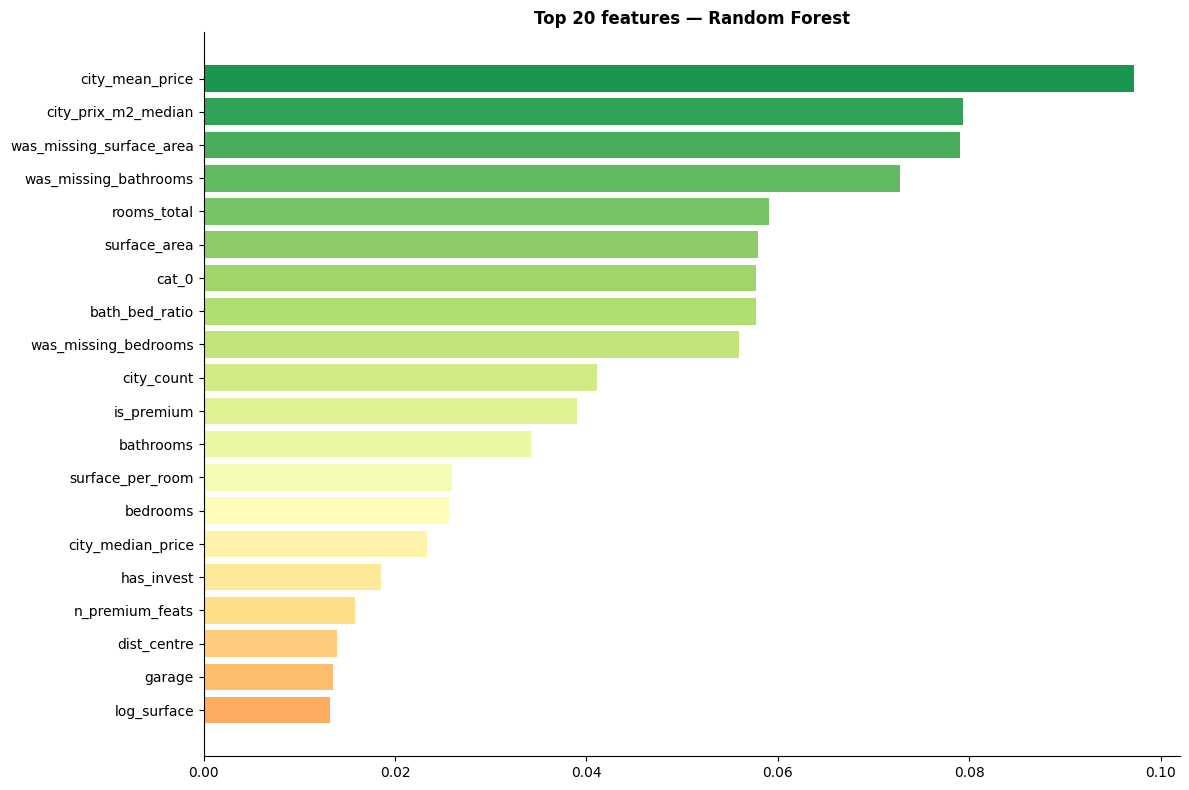

  GRADIENT BOOSTING
  lr=0.03 -> R2=0.3853
  lr=0.05 -> R2=0.3794
  lr=0.1 -> R2=0.4022
  R2 test    : 0.4198  [manque 0.4802]
  R2 train   : 0.7393  [SURAPPRENTISSAGE] (gap=0.3195)
  MAE        :      48,840,750 FCFA
  RMSE       :      93,884,290 FCFA
  MAPE       : 169.33 %
  Pct ±20%   : 24.3 % des prédictions dans la fourchette ±20%
  CV R2      : 0.4644 ± 0.1334
  Temps      : 5.9 s


In [6]:
# ── 9. RANDOM FOREST ────────────────────────────────────────────────────────
print("="*60); print("  RANDOM FOREST"); print("="*60)
ns = [100,200,300,500]
print("Test n_estimators :")
r2s = []
for n in ns:
    p  = build_pipeline(RandomForestRegressor(n_estimators=n,random_state=42,n_jobs=-1),use_log=True)
    p.fit(X_train, yl_train)
    re = r2_score(y_test.values, np.expm1(p.predict(X_test)))
    r2s.append(re); print(f"  n={n:>3} -> R2={re:.4f}")

best_n = ns[np.argmax(r2s)]
r = evaluate("Random Forest",
             build_pipeline(RandomForestRegressor(n_estimators=best_n, max_features="sqrt",
                            random_state=42, n_jobs=-1)), use_log=True)
show("Random Forest", r)

# Importance features Random Forest
imp    = r["pipeline"].named_steps["model"].feature_importances_
fn_imp = num_feats + [f"cat_{i}" for i in range(len(imp)-len(num_feats))]
imp_df = (pd.DataFrame({"Feature":fn_imp[:len(imp)],"Importance":imp})
          .sort_values("Importance",ascending=True).tail(20))
fig, ax = plt.subplots(figsize=(12,8))
ax.barh(imp_df["Feature"], imp_df["Importance"],
        color=plt.cm.RdYlGn(np.linspace(0.3,0.9,len(imp_df))))
ax.set_title("Top 20 features — Random Forest", fontweight="bold")
plt.tight_layout(); plt.savefig("fig_rf_importance.png", dpi=150, bbox_inches="tight"); plt.show()

# ── 10. GRADIENT BOOSTING ────────────────────────────────────────────────────
print(""+"="*60); print("  GRADIENT BOOSTING"); print("="*60)
for lr in [0.03,0.05,0.1]:
    p  = build_pipeline(GradientBoostingRegressor(n_estimators=200,learning_rate=lr,
                         max_depth=5,random_state=42), use_log=True)
    p.fit(X_train, yl_train)
    re = r2_score(y_test.values, np.expm1(p.predict(X_test)))
    print(f"  lr={lr} -> R2={re:.4f}")

r = evaluate("Gradient Boosting",
             build_pipeline(GradientBoostingRegressor(n_estimators=500,learning_rate=0.05,
                            max_depth=5,subsample=0.8,min_samples_split=5,random_state=42)),
             use_log=True)
show("Gradient Boosting", r)


In [7]:
# ── 11. XGBOOST ─────────────────────────────────────────────────────────────
print("="*60); print("  XGBOOST"); print("="*60)
if XGBOOST:
    r = evaluate("XGBoost",
                 build_pipeline(XGBRegressor(n_estimators=1000,learning_rate=0.03,max_depth=6,
                                subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,
                                min_child_weight=3,random_state=42,verbosity=0,n_jobs=-1)),
                 use_log=True)
    show("XGBoost", r)
else:
    print("XGBoost non disponible.")

# ── 12. LIGHTGBM ────────────────────────────────────────────────────────────
print(""+"="*60); print("  LIGHTGBM (plus rapide qu'XGBoost sur grands datasets)"); print("="*60)
if LIGHTGBM:
    r = evaluate("LightGBM",
                 build_pipeline(LGBMRegressor(n_estimators=1000,learning_rate=0.03,max_depth=6,
                                num_leaves=63,subsample=0.8,colsample_bytree=0.8,
                                reg_alpha=0.1,reg_lambda=1.0,min_child_samples=10,
                                random_state=42,verbose=-1,n_jobs=-1)),
                 use_log=True)
    show("LightGBM", r)
else:
    print("LightGBM non disponible — pip install lightgbm")

# ── 13. STACKING (architecture gagnante Kaggle) ──────────────────────────────
print(""+"="*60)
print("  STACKING XGBoost + LightGBM + Random Forest -> ElasticNet")
print("  (Solutions gagnantes Kaggle House Prices)")
print("="*60)

estimators = []
if XGBOOST:
    estimators.append(("xgb", build_pipeline(XGBRegressor(n_estimators=500,learning_rate=0.05,
                       max_depth=6,subsample=0.8,random_state=42,verbosity=0,n_jobs=-1))))
if LIGHTGBM:
    estimators.append(("lgb", build_pipeline(LGBMRegressor(n_estimators=500,learning_rate=0.05,
                       num_leaves=63,subsample=0.8,random_state=42,verbose=-1,n_jobs=-1))))
estimators.append(("rf",  build_pipeline(RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1))))
estimators.append(("ridge",build_pipeline(Ridge(alpha=100))))

if len(estimators) >= 2:
    meta_learner = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
    stacking = StackingRegressor(estimators=estimators, final_estimator=meta_learner, cv=5, n_jobs=-1)
    print(f"  Estimateurs de base : {[e[0] for e in estimators]}")
    print(f"  Meta-learner        : ElasticNet")
    r = evaluate("Stacking", stacking, use_log=True)
    show("Stacking", r)
else:
    print("Pas assez de modèles pour le stacking (installer XGBoost et/ou LightGBM).")


  XGBOOST
  R2 test    : 0.3768  [manque 0.5232]
  R2 train   : 0.7492  [SURAPPRENTISSAGE] (gap=0.3724)
  MAE        :      51,639,796 FCFA
  RMSE       :      97,306,670 FCFA
  MAPE       : 197.01 %
  Pct ±20%   : 26.7 % des prédictions dans la fourchette ±20%
  CV R2      : 0.4765 ± 0.1096
  Temps      : 2.6 s
  LIGHTGBM (plus rapide qu'XGBoost sur grands datasets)
  R2 test    : 0.3763  [manque 0.5237]
  R2 train   : 0.6591  [SURAPPRENTISSAGE] (gap=0.2828)
  MAE        :      51,936,472 FCFA
  RMSE       :      97,347,454 FCFA
  MAPE       : 175.49 %
  Pct ±20%   : 21.3 % des prédictions dans la fourchette ±20%
  CV R2      : 0.4755 ± 0.1174
  Temps      : 1.4 s
  STACKING XGBoost + LightGBM + Random Forest -> ElasticNet
  (Solutions gagnantes Kaggle House Prices)
  Estimateurs de base : ['xgb', 'lgb', 'rf', 'ridge']
  Meta-learner        : ElasticNet
  R2 test    : 0.4007  [manque 0.4993]
  R2 train   : 0.5610  [SURAPPRENTISSAGE] (gap=0.1603)
  MAE        :      49,974,063 FCFA
  R

## 14. SHAP — Interprétabilité du modèle

Modèle retenu pour SHAP : Gradient Boosting (R2=0.4198)


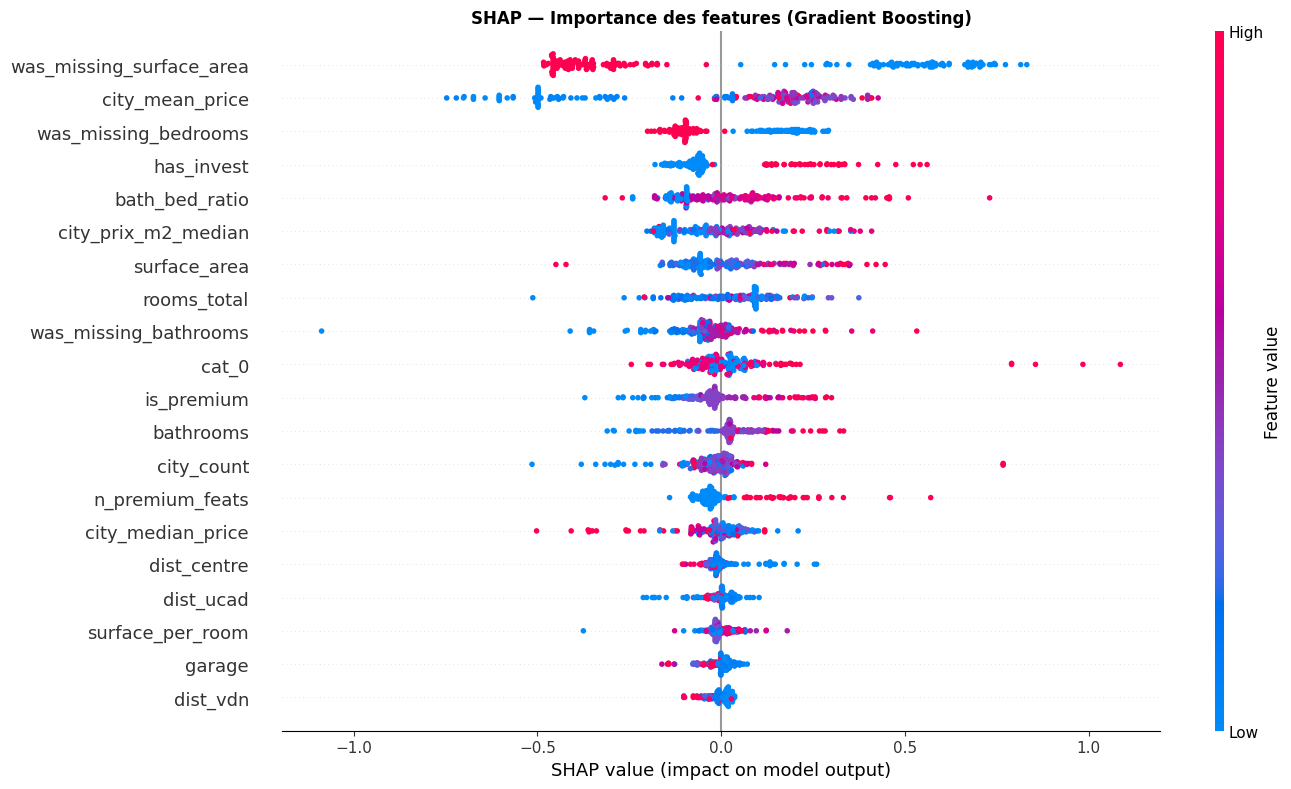

Graphique SHAP sauvegardé.


In [8]:
# SHAP (SHapley Additive exPlanations) — demandé par les institutions B2G
# Permet d'expliquer POURQUOI le modèle prédit un certain prix
# Recommandé par l'étude Financial Innovation (2025) pour les AVM institutionnels

best_model_name = max(
    [k for k in RESULTS if k not in ("Baseline","Lineaire (brut)")],
    key=lambda k: RESULTS[k]["R2 test"]
)
print(f"Modèle retenu pour SHAP : {best_model_name} (R2={RESULTS[best_model_name]['R2 test']:.4f})")

best_pipe = RESULTS[best_model_name]["pipeline"]

if SHAP:
    try:
        prep_X = best_pipe.named_steps["prep"].transform(X_test)
        model  = best_pipe.named_steps["model"]

        # XGBoost / LightGBM / RF supportent le TreeExplainer (rapide)
        explainer  = shap.TreeExplainer(model)
        shap_vals  = explainer.shap_values(prep_X[:200])

        feat_names = (num_feats +
                      [f"cat_{i}" for i in range(prep_X.shape[1]-len(num_feats))])[:prep_X.shape[1]]

        plt.figure(figsize=(14,8))
        shap.summary_plot(shap_vals, prep_X[:200],
                          feature_names=feat_names, show=False, plot_size=(14,8))
        plt.title(f"SHAP — Importance des features ({best_model_name})", fontweight="bold")
        plt.tight_layout()
        plt.savefig("../outputs/fig_shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Graphique SHAP sauvegardé.")
    except Exception as e:
        print(f"SHAP non compatible avec ce modèle : {e}")
        print("Astuce : SHAP TreeExplainer fonctionne avec XGBoost, LightGBM, Random Forest.")
else:
    print("SHAP non installé. pip install shap")
    print("L'interprétabilité SHAP est recommandée pour la diffusion B2G (ICTD, 2023).")


## 15. Comparaison finale

In [9]:
rows = []
for name, res in RESULTS.items():
    rows.append({
        "Modele": name, "R2 test": res["R2 test"], "R2 train": res["R2 train"],
        "MAE": res["MAE"], "RMSE": res["RMSE"], "MAPE": res["MAPE"],
        "Pct20": res["Pct20"], "CV R2": res["CV R2"], "CV std": res["CV std"],
        "Overfit": res["Overfit"], "Temps (s)": res["Temps"],
    })

mdf = (pd.DataFrame(rows).sort_values("R2 test",ascending=False).reset_index(drop=True))
mdf.index += 1
print("CLASSEMENT FINAL :")
print(mdf.to_string())


CLASSEMENT FINAL :
               Modele  R2 test  R2 train          MAE          RMSE    MAPE  Pct20   CV R2  CV std  Overfit  Temps (s)
1     Lineaire (brut)   0.4277    0.4106  58993044.45  9.324295e+07  346.53   18.1  0.3509  0.0930  -0.0172        0.1
2   Gradient Boosting   0.4198    0.7393  48840750.08  9.388429e+07  169.33   24.3  0.4644  0.1334   0.3194        5.9
3            Stacking   0.4007    0.5610  49974062.99  9.542029e+07  156.36   23.5  0.5174  0.1043   0.1603       27.5
4             XGBoost   0.3768    0.7492  51639796.02  9.730667e+07  197.01   26.7  0.4765  0.1096   0.3725        2.6
5            LightGBM   0.3763    0.6591  51936472.11  9.734745e+07  175.49   21.3  0.4755  0.1174   0.2828        1.4
6       Random Forest   0.3672    0.6566  51074124.05  9.804942e+07  152.41   23.7  0.4982  0.1308   0.2894        0.9
7               Ridge   0.3095    0.2110  56624867.58  1.024243e+08  169.88   17.0  0.4464  0.0863  -0.0985        0.0
8               Lasso   0.308

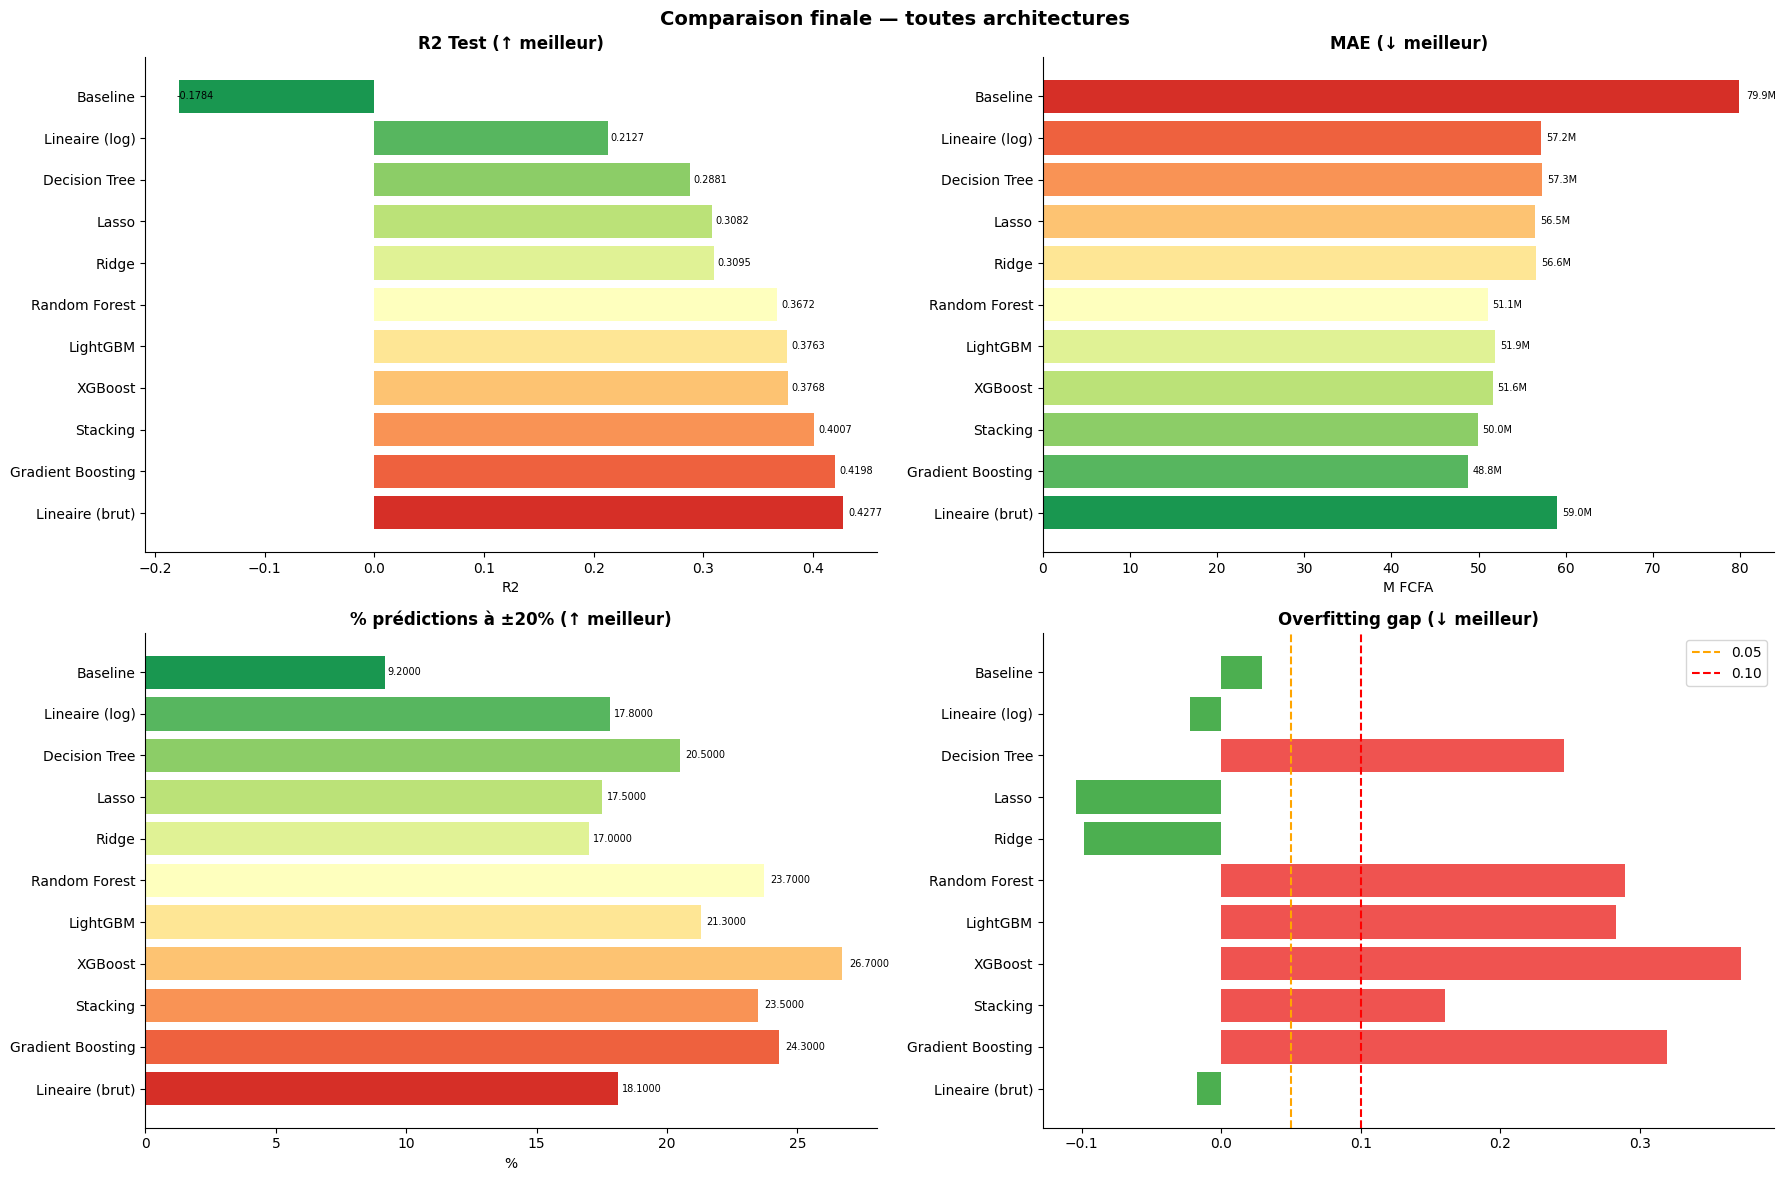

In [10]:
fig, axes = plt.subplots(2,2, figsize=(18,12))
names  = mdf["Modele"].tolist()
colors = plt.cm.RdYlGn(np.linspace(0.1,0.9,len(names)))

def hbar(ax, vals, title, xlabel, div=1, inv=False):
    c    = colors[::-1] if inv else colors
    bars = ax.barh(names, [v/div for v in vals], color=c)
    ax.set_title(title, fontweight="bold"); ax.set_xlabel(xlabel)
    for bar, v in zip(bars, vals):
        ax.text(v/div*1.01, bar.get_y()+bar.get_height()/2,
                f"{v/div:.4f}" if div==1 else f"{v/div:.1f}M", va="center", fontsize=7)

hbar(axes[0,0], mdf["R2 test"].values,  "R2 Test (↑ meilleur)", "R2")
hbar(axes[0,1], mdf["MAE"].values,      "MAE (↓ meilleur)",     "M FCFA", div=1e6, inv=True)
hbar(axes[1,0], mdf["Pct20"].values,    "% prédictions à ±20% (↑ meilleur)", "%")
ov = mdf["Overfit"].values
col_ov = ["#ef5350" if v>0.1 else "#ff9800" if v>0.05 else "#4CAF50" for v in ov]
axes[1,1].barh(names, ov, color=col_ov)
axes[1,1].axvline(0.05,color="orange",linestyle="--",label="0.05")
axes[1,1].axvline(0.10,color="red",   linestyle="--",label="0.10")
axes[1,1].set_title("Overfitting gap (↓ meilleur)", fontweight="bold")
axes[1,1].legend()
plt.suptitle("Comparaison finale — toutes architectures", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("../outputs/fig_comparaison.png", dpi=150, bbox_inches="tight"); plt.show()


In [11]:
medals = ["1","2","3"] + ["  "]*20
best   = mdf.iloc[0]["Modele"]
base   = RESULTS["Baseline"]["R2 test"]

print("="*65); print("  PODIUM FINAL"); print("="*65)
for i, (_,row) in enumerate(mdf.iterrows()):
    m   = medals[i]
    obj = "OBJECTIF R2>=0.90 ATTEINT" if row["R2 test"]>=0.90 else f"manque {0.90-row['R2 test']:.4f}"
    print(f"{m} {row['Modele']}")
    print(f"     R2 test  : {row['R2 test']:.4f}  [{obj}]")
    print(f"     Pct ±20% : {row['Pct20']:.1f} %  | MAE : {row['MAE']:,.0f} FCFA")
    print(f"     CV R2    : {row['CV R2']:.4f} ± {row['CV std']:.4f}")

print(f"Modèle retenu pour NB4 : {best}")

res_save = {
    name: {k:float(v) if isinstance(v,(float,int,np.floating,np.integer)) else str(v)
           for k,v in res.items() if k not in ("pipeline","y_pred","cv_scores")}
    for name,res in RESULTS.items()}
res_save["best_model"] = best
with open("comparison_results.json","w") as f:
    json.dump(res_save, f, indent=2)
print("comparison_results.json sauvegardé.")


  PODIUM FINAL
1 Lineaire (brut)
     R2 test  : 0.4277  [manque 0.4723]
     Pct ±20% : 18.1 %  | MAE : 58,993,044 FCFA
     CV R2    : 0.3509 ± 0.0930
2 Gradient Boosting
     R2 test  : 0.4198  [manque 0.4802]
     Pct ±20% : 24.3 %  | MAE : 48,840,750 FCFA
     CV R2    : 0.4644 ± 0.1334
3 Stacking
     R2 test  : 0.4007  [manque 0.4993]
     Pct ±20% : 23.5 %  | MAE : 49,974,063 FCFA
     CV R2    : 0.5174 ± 0.1043
   XGBoost
     R2 test  : 0.3768  [manque 0.5232]
     Pct ±20% : 26.7 %  | MAE : 51,639,796 FCFA
     CV R2    : 0.4765 ± 0.1096
   LightGBM
     R2 test  : 0.3763  [manque 0.5237]
     Pct ±20% : 21.3 %  | MAE : 51,936,472 FCFA
     CV R2    : 0.4755 ± 0.1174
   Random Forest
     R2 test  : 0.3672  [manque 0.5328]
     Pct ±20% : 23.7 %  | MAE : 51,074,124 FCFA
     CV R2    : 0.4982 ± 0.1308
   Ridge
     R2 test  : 0.3095  [manque 0.5905]
     Pct ±20% : 17.0 %  | MAE : 56,624,868 FCFA
     CV R2    : 0.4464 ± 0.0863
   Lasso
     R2 test  : 0.3082  [manque 0.5918